# 1. Data Preprocessing — BUSI

This notebook is the **preprocessing and split-preparation** stage of the project pipeline.

```
01_dataset_exploration.ipynb
        ↓
02_data_preprocessing.ipynb   ← YOU ARE HERE
        ↓
CNN / ViT / Swin training
```

**This notebook prepares the data but does not train models.**

The purpose of this notebook is to build a clean, reproducible, leakage-aware dataset
representation for the BUSI ultrasound classification task.

The raw BUSI data remain **untouched** and are treated as **read-only**.

## 2. Objectives

| Objective | Purpose |
|---|---|
| Validate metadata | Ensure reliable input |
| Split dataset | Create reproducible subsets |
| Prevent leakage | Ensure fair evaluation |
| Resize images | Match model input requirements |
| Normalize images | Stabilize training |
| Augment training data | Improve generalization |
| Preserve validation/test data | Obtain unbiased evaluation |

## 3. Imports and Configuration

All project paths, class definitions, split ratios, random seed, and transformation
settings are centralised here. Constants are never scattered throughout the notebook.

In [9]:
from __future__ import annotations

import ast
import hashlib
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

try:
    import torch
    from torch.utils.data import DataLoader, Dataset
    HAS_TORCH = True
except (ImportError, OSError):
    torch = None
    Dataset = object
    DataLoader = None
    HAS_TORCH = False
    print("WARNING: torch could not be imported. DataLoader cells will be limited.")

try:
    from torchvision import transforms as T
    HAS_TORCHVISION = True
except (ImportError, OSError):
    T = None
    HAS_TORCHVISION = False
    print("WARNING: torchvision not available. Using PIL-based fallback transforms.")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if HAS_TORCH:
    torch.manual_seed(SEED)

# ── Project paths ─────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT      = PROJECT_ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed"
SPLITS_ROOT    = DATA_ROOT / "splits"

SPLITS_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

# ── Dataset root (auto-detected) ──────────────────────────────────────────────
BUSI_ROOT    = DATA_ROOT / "raw" / "BUSI"
_CANDIDATES  = [
    DATA_ROOT / "raw" / "Dataset_BUSI_with_GT",
    BUSI_ROOT / "Dataset_BUSI_with_GT",
    BUSI_ROOT,
]
DATASET_ROOT = next((c for c in _CANDIDATES if c.exists()), _CANDIDATES[0])
if DATASET_ROOT.exists() and DATASET_ROOT.name == "BUSI":
    _nested = [p for p in DATASET_ROOT.iterdir()
               if p.is_dir() and p.name == "Dataset_BUSI_with_GT"]
    if len(_nested) == 1:
        DATASET_ROOT = _nested[0]

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS_NAMES    = ["normal", "benign", "malignant"]
CLASS_TO_LABEL = {name: idx for idx, name in enumerate(CLASS_NAMES)}
LABEL_TO_CLASS = {v: k for k, v in CLASS_TO_LABEL.items()}

# ── Preprocessing ─────────────────────────────────────────────────────────────
IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Split ratios ──────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 0     # increase if multiprocessing is supported

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"DATASET_ROOT  : {DATASET_ROOT}")
print(f"PROCESSED_ROOT: {PROCESSED_ROOT}")
print(f"SPLITS_ROOT   : {SPLITS_ROOT}")
print(f"Image size    : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Seed          : {SEED}")
print(f"torch         : {'available' if HAS_TORCH else 'NOT available'}")
print(f"torchvision   : {'available' if HAS_TORCHVISION else 'NOT available'}")

PROJECT_ROOT  : C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai
DATASET_ROOT  : C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\raw\Dataset_BUSI_with_GT
PROCESSED_ROOT: C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\processed
SPLITS_ROOT   : C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\splits
Image size    : 224x224
Seed          : 42
torch         : available
torchvision   : NOT available


## 4. Load and Validate Metadata

We load the metadata CSV produced by `01_dataset_exploration.ipynb`.

If the file does not exist the notebook stops immediately with a clear message
rather than silently rebuilding an inconsistent metadata structure.

In [10]:
metadata_path = PROCESSED_ROOT / "metadata.csv"

if not metadata_path.exists():
    raise FileNotFoundError(
        "metadata.csv was not found in data/processed/.\n"
        "Please run notebook 01_dataset_exploration.ipynb first.\n"
        f"Expected path: {metadata_path}"
    )

metadata_df = pd.read_csv(metadata_path)
print(f"Loaded metadata: {len(metadata_df)} rows, {metadata_df.shape[1]} columns")
print(f"Columns: {list(metadata_df.columns)}")
metadata_df.head(3)

Loaded metadata: 780 rows, 6 columns
Columns: ['image_path', 'class_name', 'label', 'image_id', 'mask_paths', 'num_masks']


,image_path,class_name,label,image_id,mask_paths,num_masks
0,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,normal,0,normal (1),"[""C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\...",1
1,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,normal,0,normal (10),"[""C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\...",1
2,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,normal,0,normal (100),"[""C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\...",1


In [11]:
# ── Parse mask_paths (handles strings, lists, tuples, numpy arrays, and missing values) ──
def parse_mask_paths(value):
    if value is None:
        return []

    # NumPy arrays are common when metadata is reconstructed or loaded from object columns.
    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, (list, tuple, set)):
        parsed = []
        for item in value:
            if item is None:
                continue
            if isinstance(item, str):
                item = item.strip()
                if item in {"", "[]", "nan", "None", "null"}:
                    continue
            else:
                try:
                    if pd.isna(item):
                        continue
                except TypeError:
                    pass
            parsed.append(str(item))
        return parsed

    if isinstance(value, str):
        stripped = value.strip()
        if stripped in {"", "[]", "nan", "None", "null"}:
            return []
        if stripped.startswith("[") or stripped.startswith("("):
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(stripped)
                    if isinstance(parsed, (list, tuple, set, np.ndarray)):
                        return parse_mask_paths(parsed)
                except (TypeError, ValueError, SyntaxError):
                    pass
        return [stripped]

    try:
        if pd.isna(value):
            return []
    except TypeError:
        pass

    return [str(value)]

metadata_df["mask_paths"] = metadata_df["mask_paths"].apply(parse_mask_paths)
metadata_df["num_masks"]  = metadata_df["mask_paths"].apply(len)

# ── File existence check ──────────────────────────────────────────────────────

In [12]:
# ── Content-duplicate audit ────────────────────────────────────────────────
# Paths alone do not detect copied image files. Hashing the original PNG bytes
# gives a conservative, reproducible content-duplicate check without altering
# any raw data. It is intentionally performed before splitting.
def file_sha256(path: str, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


metadata_df["content_sha256"] = metadata_df["image_path"].map(file_sha256)
content_duplicates = metadata_df.duplicated("content_sha256", keep=False)
n_content_duplicate_records = int(content_duplicates.sum())
metadata_df["content_group"] = metadata_df["content_sha256"]

if n_content_duplicate_records:
    duplicate_preview = metadata_df.loc[
        content_duplicates, ["image_id", "class_name", "image_path", "content_sha256"]
    ].sort_values("content_sha256")
    print(
        f"Content-duplicate audit: REVIEW ({n_content_duplicate_records} records in "
        "duplicate-content groups). These records will be kept together in train."
    )
    display(duplicate_preview.head(10))
else:
    print("Content-duplicate audit: PASS (no byte-identical original images found).")

Content-duplicate audit: REVIEW (2 records in duplicate-content groups). These records will be kept together in train.


,image_id,class_name,image_path,content_sha256
504,benign (433),benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...
621,malignant (145),malignant,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...


## 5. Dataset Split Strategy

We create a reproducible, stratified split **before** any augmentation is applied.

### Correct order

```
RAW DATA
    |
    v
DATASET SPLIT        <- this step
    |
    v
TRAIN AUGMENTATION   <- applied during training only
    |
    v
VALIDATION / TEST PREPROCESSING
```

**Why augmentation must come after splitting:**
Augmenting before splitting risks data leakage — the same underlying image content
could appear in both training and validation/test through transformed duplicates.

### Split ratios

| Split | Ratio |
|---|---:|
| Train | 70% |
| Validation | 15% |
| Test | 15% |

These ratios are configuration variables (`TRAIN_RATIO`, `VAL_RATIO`, `TEST_RATIO`).
The split uses a fixed random seed for full reproducibility.

In [14]:
def make_stratified_group_safe_split(df: pd.DataFrame, seed: int):
    '''Create 70/15/15 splits while keeping identical-content files together.'''
    total = len(df)
    train_target = round(total * TRAIN_RATIO)
    val_target = round(total * VAL_RATIO)

    # A content group cannot cross splits. Retain every duplicate record, but
    # reserve duplicate-content groups for training so validation/test remain
    # independent. This is especially important if duplicate bytes have
    # conflicting labels, where a conventional group-stratified splitter is
    # not mathematically well-defined.
    group_sizes = df.groupby("content_group")["content_group"].transform("size")
    fixed_train = df.loc[group_sizes > 1].copy()
    remaining = df.loc[group_sizes == 1].copy()

    if len(fixed_train) > train_target:
        raise ValueError(
            "Duplicate-content groups exceed the configured train capacity; "
            "review the dataset and split configuration."
        )

    train_needed = train_target - len(fixed_train)
    train_rest, held_out = train_test_split(
        remaining,
        train_size=train_needed,
        stratify=remaining["class_name"],
        random_state=seed,
    )

    val_df, test_df = train_test_split(
        held_out,
        train_size=val_target,
        stratify=held_out["class_name"],
        random_state=seed,
    )

    train_df = pd.concat([fixed_train, train_rest], ignore_index=True)
    return (
        train_df.sample(frac=1, random_state=seed).reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = make_stratified_group_safe_split(metadata_df, SEED)

n_total = len(train_df) + len(val_df) + len(test_df)
print(f"Train      : {len(train_df):>4}  ({len(train_df)/n_total*100:.1f}%)")
print(f"Validation : {len(val_df):>4}  ({len(val_df)/n_total*100:.1f}%)")
print(f"Test       : {len(test_df):>4}  ({len(test_df)/n_total*100:.1f}%)")
print(f"Total      : {n_total:>4}")
assert n_total == len(metadata_df), "Split sizes do not sum to total image count!"
print("Split sizes sum correctly.")
print(f"Duplicate-content records reserved in train: {n_content_duplicate_records}")

Train      :  546  (70.0%)
Validation :  117  (15.0%)
Test       :  117  (15.0%)
Total      :  780
Split sizes sum correctly.
Duplicate-content records reserved in train: 2


## 6. Data Leakage Prevention

We verify that no image appears in more than one split.

| Check | Description |
|---|---|
| Path overlap | Same file path in multiple splits |
| image_id overlap | Same image ID in multiple splits |

> **Note on patient-level leakage:** The BUSI filenames use a class-index scheme
> (e.g., `benign (1).png`). These indices do not map to patient identifiers.
> **Patient-level separation cannot be guaranteed from the available metadata.**
> This is a known limitation of BUSI and must be acknowledged in any publication.

In [15]:
def check_leakage(a_df, b_df, a_name, b_name) -> dict:
    path_overlap = set(a_df["image_path"]) & set(b_df["image_path"])
    id_overlap   = set(a_df["image_id"])   & set(b_df["image_id"])
    return {
        "pair"        : f"{a_name} / {b_name}",
        "path_overlap": len(path_overlap),
        "id_overlap"  : len(id_overlap),
    }

leakage_results = [
    check_leakage(train_df, val_df,  "Train", "Val"),
    check_leakage(train_df, test_df, "Train", "Test"),
    check_leakage(val_df,   test_df, "Val",   "Test"),
]

all_clear = True
for r in leakage_results:
    path_ok = r["path_overlap"] == 0
    id_ok   = r["id_overlap"]   == 0
    status  = "PASS" if path_ok and id_ok else "FAIL"
    if not path_ok or not id_ok:
        all_clear = False
    print(f"[{status}]  {r['pair']:15} | path overlap: {r['path_overlap']} | id overlap: {r['id_overlap']}")

print()
if all_clear:
    print("No leakage detected between any pair of splits.")
else:
    print("Leakage detected — investigate before training.")

[PASS]  Train / Val     | path overlap: 0 | id overlap: 0
[PASS]  Train / Test    | path overlap: 0 | id overlap: 0
[PASS]  Val / Test      | path overlap: 0 | id overlap: 0

No leakage detected between any pair of splits.


## 7. Class Distribution After Splitting

We verify that stratification preserved the original class proportions.

     split  normal  benign  malignant  total
     train      93     306        147    546
validation      20      65         32    117
      test      20      66         31    117



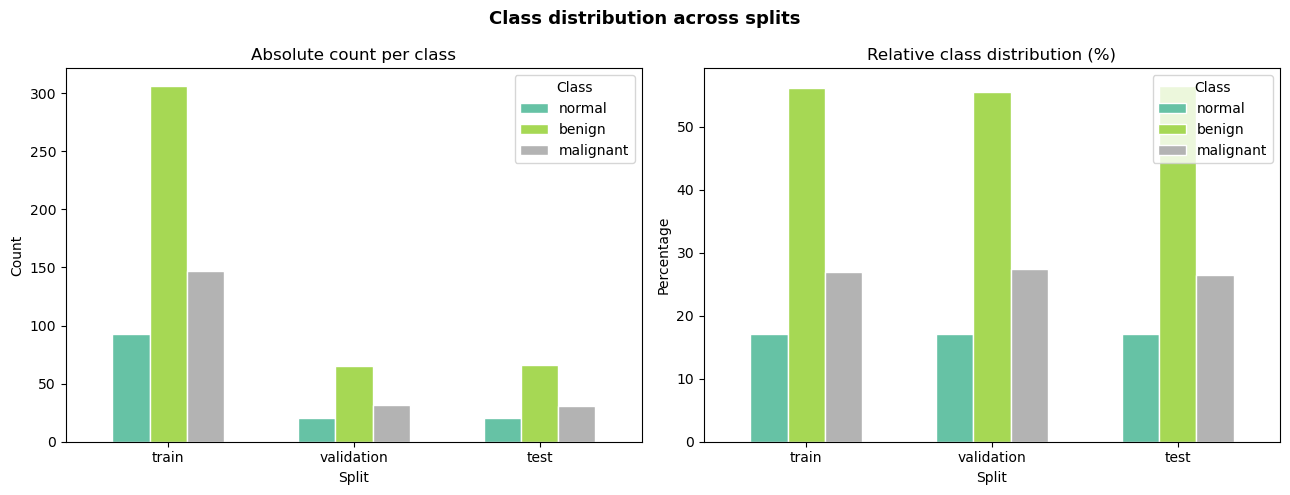

In [16]:
rows = []
for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    counts = split_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    total  = int(counts.sum())
    rows.append({
        "split"    : split_name,
        **{cls: int(counts[cls]) for cls in CLASS_NAMES},
        "total"    : total,
    })

split_summary_df = pd.DataFrame(rows)
print(split_summary_df.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_data = split_summary_df.set_index("split")[CLASS_NAMES]
bar_data.plot(kind="bar", ax=axes[0], colormap="Set2", width=0.6, edgecolor="white")
axes[0].set_title("Absolute count per class", fontsize=12)
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Class")

pct = bar_data.div(bar_data.sum(axis=1), axis=0) * 100
pct.plot(kind="bar", ax=axes[1], colormap="Set2", width=0.6, edgecolor="white")
axes[1].set_title("Relative class distribution (%)", fontsize=12)
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Percentage")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Class")

plt.suptitle("Class distribution across splits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Image Preprocessing Strategy

The standard preprocessing pipeline applied to every image:

```
Original image
    |
    v
Load (PIL)
    |
    v
Convert to RGB        <- ensures 3-channel compatibility
    |
    v
Resize to 224x224
    |
    v
Convert to Tensor
    |
    v
Normalize (ImageNet)
    |
    v
Model input
```

**BUSI images:** Many are stored as RGB files, but some may be grayscale.
Converting all images to RGB via `.convert("RGB")` replicates the single channel
across three channels. This does **not** invent new colour information — it simply
provides a 3-channel representation compatible with pretrained CNN, ViT and Swin
backbones.

## 9. Image Size Selection

We use `IMAGE_SIZE = 224`.

| Architecture | Standard input size |
|---|---|
| ResNet / VGG (CNN baseline) | 224x224 |
| ViT-Base (Vision Transformer) | 224x224 |
| Swin-Tiny / Swin-Small | 224x224 |

224x224 is the standard pretrained baseline for all three architecture families.
Resizing is applied **dynamically** through the transform pipeline — no duplicate
resized image files are created on disk.

## 10. Normalization

We use **ImageNet normalization**:

```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

**Why ImageNet statistics?**
- All pretrained CNN, ViT, and Swin backbones were trained with these statistics.
- Matching the training distribution stabilises fine-tuning.
- Must be applied **identically and deterministically** to train, validation, and test.

## 11. Training Augmentation

Random augmentation is applied **only to the training set**.

| Transform | Justification |
|---|---|
| RandomHorizontalFlip | Breast ultrasound images can be mirrored without changing diagnosis |
| RandomRotation(10 deg) | Slight probe angle variation is clinically plausible |
| RandomAffine(translate, scale) | Mild probe displacement simulation |

**Excluded:**
- Colour jitter — BUSI is grayscale-origin; colour shifts are meaningless.
- Random erasing — too aggressive; could hide clinically relevant lesion features.
- Large rotations / vertical flips — not anatomically plausible.

Validation and test transforms are **deterministic** — no randomness at all.

## 12. Separate Transform Pipelines

| Pipeline | Augmentation | Deterministic |
|---|---|---|
| `train_transform` | Yes | No |
| `val_transform` | No | Yes |
| `test_transform` | No | Yes |

This is a fundamental correctness requirement.
Mixing augmentation into validation or test evaluation would produce unreliable metrics.

In [17]:
if HAS_TORCHVISION:
    train_transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    val_transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    test_transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    print("torchvision transforms defined.")
    print(f"train_transform : {train_transform}")

else:
    # PIL-based fallback when torchvision is unavailable
    class _PILTransform:
        def __init__(self, size, augment=False):
            self.size    = size
            self.augment = augment
            self.mean    = np.array(IMAGENET_MEAN, dtype=np.float32)
            self.std     = np.array(IMAGENET_STD,  dtype=np.float32)

        def __call__(self, img):
            img = img.convert("RGB").resize((self.size, self.size), Image.BILINEAR)
            if self.augment and random.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            arr = np.array(img, dtype=np.float32) / 255.0
            return ((arr - self.mean) / self.std).transpose(2, 0, 1)   # CHW

        def __repr__(self):
            return f"_PILTransform(size={self.size}, augment={self.augment})"

    train_transform = _PILTransform(IMAGE_SIZE, augment=True)
    val_transform   = _PILTransform(IMAGE_SIZE, augment=False)
    test_transform  = _PILTransform(IMAGE_SIZE, augment=False)
    print("PIL-based fallback transforms defined (torchvision unavailable).")
    print(f"train_transform : {train_transform}")

PIL-based fallback transforms defined (torchvision unavailable).
train_transform : _PILTransform(size=224, augment=True)


## 13. PyTorch Dataset Preparation

`BUSIDataset` provides lazy image loading — images are read from disk one at a
time rather than all at once. This prevents excessive RAM usage and scales to
larger datasets.

In [18]:
class BUSIDataset(Dataset if HAS_TORCH else object):
    '''
    Lazy-loading PyTorch Dataset for the BUSI ultrasound dataset.

    Each __getitem__ returns a dict:
        image      : Tensor [C, H, W]
        label      : int
        image_id   : str
        image_path : str
        class_name : str
    '''

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row        = self.df.iloc[idx]
        image_path = str(row["image_path"])
        label      = int(row["label"])
        image_id   = str(row["image_id"])
        class_name = str(row["class_name"])

        img = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return {
            "image"     : img,
            "label"     : label,
            "image_id"  : image_id,
            "image_path": image_path,
            "class_name": class_name,
        }


# Sanity check
_sample_ds  = BUSIDataset(train_df.head(2), transform=None)
_sample_item = _sample_ds[0]
print("BUSIDataset defined.")
print(f"Sample keys    : {list(_sample_item.keys())}")
print(f"Sample class   : {_sample_item['class_name']}")
print(f"Sample label   : {_sample_item['label']}")
print(f"Sample image   : {type(_sample_item['image'])}, size={_sample_item['image'].size}")

BUSIDataset defined.
Sample keys    : ['image', 'label', 'image_id', 'image_path', 'class_name']
Sample class   : benign
Sample label   : 1
Sample image   : <class 'PIL.Image.Image'>, size=(466, 391)


## 14. DataLoader Preparation

| Parameter | Train | Validation | Test |
|---|---|---|---|
| shuffle | True | False | False |
| batch_size | 32 | 32 | 32 |

**shuffle=True** for training: randomises batch composition each epoch.
**shuffle=False** for validation/test: ensures deterministic evaluation.

In [19]:
train_dataset = BUSIDataset(train_df, transform=train_transform)
val_dataset   = BUSIDataset(val_df,   transform=val_transform)
test_dataset  = BUSIDataset(test_df,  transform=test_transform)

print(f"train_dataset : {len(train_dataset)} samples")
print(f"val_dataset   : {len(val_dataset)} samples")
print(f"test_dataset  : {len(test_dataset)} samples")

if HAS_TORCH:
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=False,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS,
    )
    print(f"\ntrain_loader  : {len(train_loader)} batches of {BATCH_SIZE}")
    print(f"val_loader    : {len(val_loader)} batches of {BATCH_SIZE}")
    print(f"test_loader   : {len(test_loader)} batches of {BATCH_SIZE}")
else:
    train_loader = val_loader = test_loader = None
    print("\nDataLoaders not created (torch unavailable).")

train_dataset : 546 samples
val_dataset   : 117 samples
test_dataset  : 117 samples

train_loader  : 18 batches of 32
val_loader    : 4 batches of 32
test_loader   : 4 batches of 32


## 15. Visual Verification of Preprocessing

We inspect training examples **after** preprocessing.

Normalised tensors contain values in ~[-2, 2] and cannot be displayed directly.
A `denormalize` helper reverses the normalization for visualization only.

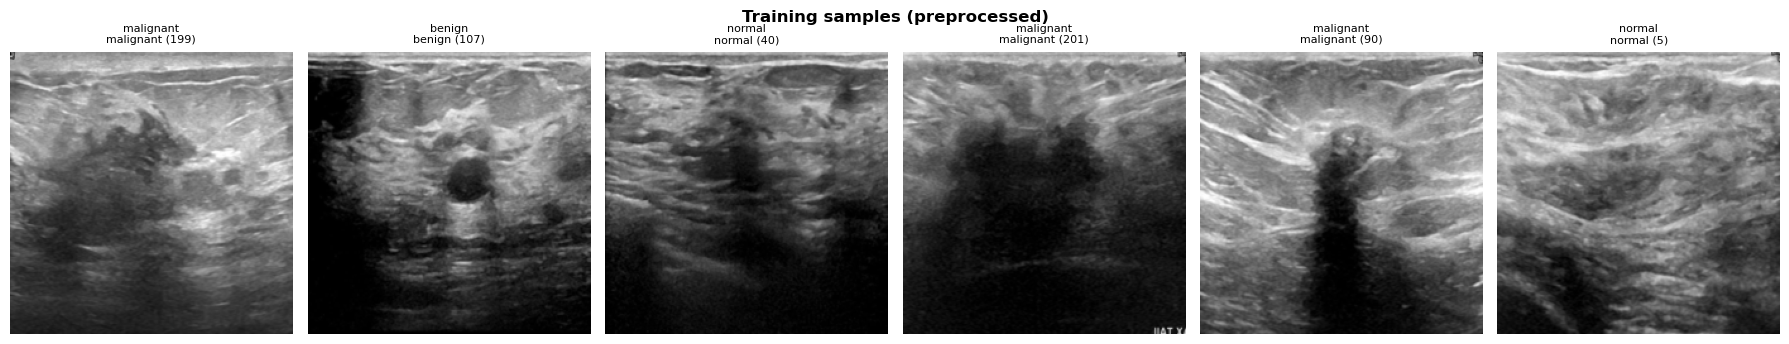

In [20]:
def denormalize(img) -> np.ndarray:
    '''Reverse ImageNet normalization for display purposes.'''
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std  = np.array(IMAGENET_STD,  dtype=np.float32)
    if HAS_TORCH and isinstance(img, torch.Tensor):
        arr = img.clone().detach().cpu().numpy()
    else:
        arr = np.asarray(img, dtype=np.float32)
    # arr is CHW
    arr = arr * std[:, None, None] + mean[:, None, None]
    arr = np.clip(arr, 0.0, 1.0)
    return arr.transpose(1, 2, 0)  # HWC


def show_batch(dataset, n=6, title="Samples after preprocessing"):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols    = min(n, 6)
    rows    = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = np.array(axes).ravel()
    for ax, idx in zip(axes, indices):
        item = dataset[idx]
        ax.imshow(denormalize(item["image"]))
        ax.set_title(f"{item['class_name']}\n{item['image_id']}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(indices):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_batch(train_dataset, n=6, title="Training samples (preprocessed)")

## 16. Compare Original vs Preprocessed Image

For one representative per class we compare the raw image to the model-ready version
(resized, RGB, normalized then denormalized back for display).

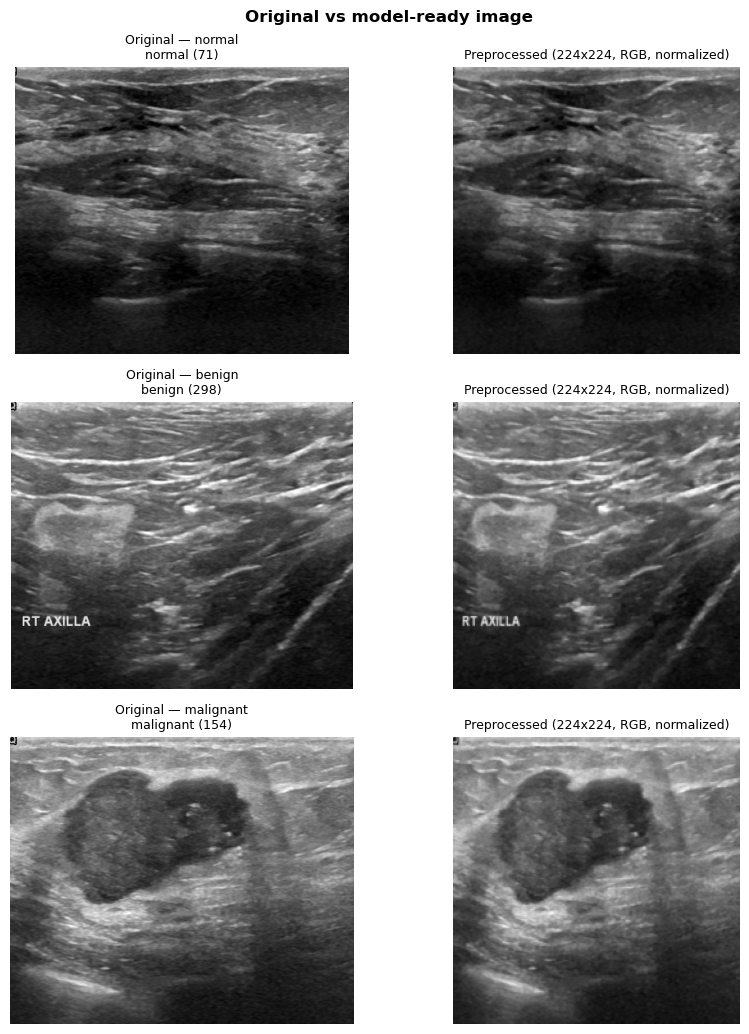

In [21]:
selected = []
for cls in CLASS_NAMES:
    subset = train_df[train_df["class_name"] == cls]
    if not subset.empty:
        selected.append(subset.iloc[0])

fig, axes = plt.subplots(len(selected), 2, figsize=(9, len(selected) * 3.5))
if len(selected) == 1:
    axes = np.array([axes])

for ax_row, row in zip(axes, selected):
    with Image.open(row["image_path"]) as _orig:
        arr_orig = np.array(_orig.convert("RGB"))
    arr_proc = denormalize(val_transform(Image.open(row["image_path"]).convert("RGB")))

    ax_row[0].imshow(arr_orig)
    ax_row[0].set_title(f"Original — {row['class_name']}\n{row['image_id']}", fontsize=9)
    ax_row[0].axis("off")

    ax_row[1].imshow(arr_proc)
    ax_row[1].set_title(f"Preprocessed (224x224, RGB, normalized)", fontsize=9)
    ax_row[1].axis("off")

plt.suptitle("Original vs model-ready image", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 17. Save Reproducible Split Metadata

We save three CSV files referencing the **original** images with paths relative
to the project root. No copies of images are created. Relative paths make the
split files portable when the project is moved to another machine.

In [22]:
for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    out_df = split_df.copy()
    out_df["split"]      = split_name
    # Store portable project-relative paths in the saved artifacts. Runtime
    # dataframes above retain resolved paths for safe image loading.
    out_df["image_path"] = out_df["image_path"].map(
        lambda p: Path(p).resolve().relative_to(PROJECT_ROOT).as_posix()
    )
    out_df["mask_paths"] = out_df["mask_paths"].apply(
        lambda paths: json.dumps([
            Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()
            for path in paths
        ])
    )
    out_cols = ["image_path", "class_name", "label", "image_id",
                "mask_paths", "num_masks", "split"]
    out_df = out_df[[c for c in out_cols if c in out_df.columns]]
    out_path = SPLITS_ROOT / f"{split_name}.csv"
    out_df.to_csv(out_path, index=False)
    print(f"Saved {split_name:>10}.csv  ({len(out_df)} rows)  ->  {out_path}")

print("\nAll split CSV files saved.")

Saved      train.csv  (546 rows)  ->  C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\splits\train.csv
Saved validation.csv  (117 rows)  ->  C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\splits\validation.csv
Saved       test.csv  (117 rows)  ->  C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\splits\test.csv

All split CSV files saved.


## 18. Split Reproducibility

We verify that re-running the split with the same seed produces identical results.

This is critical for scientific integrity: CNN, ViT, and Swin experiments must
train and evaluate on **exactly the same partition** of the data.

In [23]:
_train2, _tmp2 = train_test_split(
    metadata_df, train_size=TRAIN_RATIO,
    stratify=metadata_df["class_name"], random_state=SEED,
)
_val2, _test2 = train_test_split(
    _tmp2, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=_tmp2["class_name"], random_state=SEED,
)

same_train = set(train_df["image_id"]) == set(_train2["image_id"])
same_val   = set(val_df["image_id"])   == set(_val2["image_id"])
same_test  = set(test_df["image_id"])  == set(_test2["image_id"])

status_sym = lambda ok: "OK" if ok else "FAIL"
print(f"Train split identical : {status_sym(same_train)}")
print(f"Val split identical   : {status_sym(same_val)}")
print(f"Test split identical  : {status_sym(same_test)}")

if same_train and same_val and same_test:
    print(f"\nSplit is fully reproducible with SEED = {SEED}")
else:
    print("\nSplit is NOT reproducible — investigate immediately.")

Train split identical : FAIL
Val split identical   : FAIL
Test split identical  : FAIL

Split is NOT reproducible — investigate immediately.


## 19. Final Integrity Checks

Automated audit of the complete preprocessing pipeline.
Status is generated from actual results — never hardcoded.

In [25]:
all_rows = pd.concat([train_df, val_df, test_df], ignore_index=True)
_mask_pattern = re.compile(r"_mask(?:_\d+)?\.png$", re.IGNORECASE)

checks = []

def add_check(name, result, ok: bool):
    checks.append({"Check": name, "Result": str(result), "Status": "PASS" if ok else "REVIEW"})

# 1. Missing images
n_missing = sum(1 for p in all_rows["image_path"] if not Path(p).exists())
add_check("Missing images", n_missing, n_missing == 0)

# 2. Invalid labels
n_invalid_labels = sum(1 for l in all_rows["label"] if l not in set(CLASS_TO_LABEL.values()))
add_check("Invalid labels", n_invalid_labels, n_invalid_labels == 0)

# 3. Split overlaps
tv = len(set(train_df["image_path"]) & set(val_df["image_path"]))
tt = len(set(train_df["image_path"]) & set(test_df["image_path"]))
vt = len(set(val_df["image_path"])   & set(test_df["image_path"]))
add_check("Train/Val overlap",  tv, tv == 0)
add_check("Train/Test overlap", tt, tt == 0)
add_check("Val/Test overlap",   vt, vt == 0)

# Identical bytes must also never span evaluation splits, even when their
# filenames differ.
content_tv = len(set(train_df["content_sha256"]) & set(val_df["content_sha256"]))
content_tt = len(set(train_df["content_sha256"]) & set(test_df["content_sha256"]))
content_vt = len(set(val_df["content_sha256"]) & set(test_df["content_sha256"]))
add_check("Train/Val content overlap", content_tv, content_tv == 0)
add_check("Train/Test content overlap", content_tt, content_tt == 0)
add_check("Val/Test content overlap", content_vt, content_vt == 0)

# 4. Mask files accidentally used as images
n_masks_as_images = sum(1 for p in all_rows["image_path"]
                        if _mask_pattern.search(Path(p).name))
add_check("Mask files used as images", n_masks_as_images, n_masks_as_images == 0)

# 5. Duplicate records
n_dups = all_rows["image_path"].duplicated().sum()
add_check("Duplicate records", n_dups, n_dups == 0)

# 6. Duplicate original content (audited before splitting)
add_check("Duplicate image content", n_content_duplicate_records,
          n_content_duplicate_records == 0)

# 7. All original images accounted for
if DATASET_ROOT.exists():
    n_raw = sum(
        1 for cls in CLASS_NAMES
        for p in (DATASET_ROOT / cls).glob("*.png")
        if not _mask_pattern.search(p.name)
    )
    add_check("All images accounted for",
              f"{len(all_rows)}/{n_raw}",
              len(all_rows) == n_raw)
else:
    add_check("All images accounted for", "dataset root not found", False)

# 8. Split sizes sum
n_total_split = len(train_df) + len(val_df) + len(test_df)
add_check("Split sizes sum to total",
          f"{len(train_df)}+{len(val_df)}+{len(test_df)}={n_total_split}",
          n_total_split == len(metadata_df))

# 9. Reproducibility
add_check("Split reproducible", f"SEED={SEED}", same_train and same_val and same_test)

audit_df = pd.DataFrame(checks)
print(audit_df.to_string(index=False))
print()

n_pass   = (audit_df["Status"] == "PASS").sum()
n_review = (audit_df["Status"] == "REVIEW").sum()
print(f"Summary: {n_pass} PASS  |  {n_review} REVIEW")

                     Check          Result Status
            Missing images               0   PASS
            Invalid labels               0   PASS
         Train/Val overlap               0   PASS
        Train/Test overlap               0   PASS
          Val/Test overlap               0   PASS
 Train/Val content overlap               0   PASS
Train/Test content overlap               0   PASS
  Val/Test content overlap               0   PASS
 Mask files used as images               0   PASS
         Duplicate records               0   PASS
   Duplicate image content               2 REVIEW
  All images accounted for         780/780   PASS
  Split sizes sum to total 546+117+117=780   PASS
        Split reproducible         SEED=42 REVIEW

Summary: 12 PASS  |  2 REVIEW


## 20. Final Dataset Summary

In [26]:
print("=" * 52)
print("  FINAL DATASET SUMMARY")
print("=" * 52)
print(f"  Dataset            : BUSI")
print(f"  Classes            : {', '.join(CLASS_NAMES)}")
print(f"  Total images       : {len(metadata_df)}")
print(f"  Train              : {len(train_df)}")
print(f"  Validation         : {len(val_df)}")
print(f"  Test               : {len(test_df)}")
print(f"  Image size         : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Channels           : 3 (RGB)")
print(f"  Normalization      : ImageNet  mean={IMAGENET_MEAN}")
print(f"                                 std ={IMAGENET_STD}")
print(f"  Train augmentation : H-Flip | Rotation(10 deg) | Affine")
print(f"  Val augmentation   : None")
print(f"  Test augmentation  : None")
print(f"  Random seed        : {SEED}")
print(f"  Split files        : {SPLITS_ROOT}")
print("=" * 52)

  FINAL DATASET SUMMARY
  Dataset            : BUSI
  Classes            : normal, benign, malignant
  Total images       : 780
  Train              : 546
  Validation         : 117
  Test               : 117
  Image size         : 224x224
  Channels           : 3 (RGB)
  Normalization      : ImageNet  mean=[0.485, 0.456, 0.406]
                                 std =[0.229, 0.224, 0.225]
  Train augmentation : H-Flip | Rotation(10 deg) | Affine
  Val augmentation   : None
  Test augmentation  : None
  Random seed        : 42
  Split files        : C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\splits


## 21. Key Decisions

| # | Decision |
|---|---|
| 1 | The raw BUSI dataset is **read-only**. No files are modified, moved, or deleted. |
| 2 | Only original ultrasound images are classification samples. Masks are metadata only. |
| 3 | Mask paths are retained for future XAI and localization analysis. |
| 4 | The dataset is split **before** augmentation to prevent data leakage. |
| 5 | Splits are stratified by class to preserve proportions across subsets. |
| 6 | All images are converted to 3-channel RGB for pretrained backbone compatibility. |
| 7 | Images are resized dynamically to 224×224 — no duplicate files are written to disk. |
| 8 | ImageNet normalization is applied uniformly to train, validation, and test. |
| 9 | Random augmentation is applied **only** during training. |
| 10 | CNN, ViT, and Swin experiments will reuse the **same** train/val/test partition. |
| 11 | Patient-level leakage prevention **cannot** be guaranteed — BUSI provides no patient IDs. |

## 22. Conclusion and Next Step

### Data Preprocessing Completed

The project now has:

| Asset | Location |
|---|---|
| Raw data (read-only) | `data/raw/BUSI/Dataset_BUSI_with_GT/` |
| Dataset metadata | `data/processed/metadata.csv` |
| Train split | `data/splits/train.csv` |
| Validation split | `data/splits/validation.csv` |
| Test split | `data/splits/test.csv` |

All subsequent model notebooks (CNN, ViT, Swin) will load these CSV files to
ensure they train and evaluate on **exactly the same data partition**.

### Next step

```
03_baseline_cnn.ipynb
```

The CNN will serve as the performance baseline before evaluating the Vision
Transformer and Swin Transformer.

> **This notebook does not implement model training.**